In [37]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Dense, Input, GlobalMaxPooling1D
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Embedding
from tensorflow.keras.models import Model

In [38]:
# !wget https://lazyprogrammer.me/course_files/spam.csv

--2024-08-19 21:59:05--  https://lazyprogrammer.me/course_files/spam.csv
Resolving lazyprogrammer.me (lazyprogrammer.me)... 2606:4700:3030::ac43:d5a6, 2606:4700:3031::6815:17d2, 172.67.213.166, ...
Connecting to lazyprogrammer.me (lazyprogrammer.me)|2606:4700:3030::ac43:d5a6|:443... failed: Network is unreachable.
Connecting to lazyprogrammer.me (lazyprogrammer.me)|2606:4700:3031::6815:17d2|:443... failed: Network is unreachable.
Connecting to lazyprogrammer.me (lazyprogrammer.me)|172.67.213.166|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 503663 (492K) [text/csv]
Saving to: ‘spam.csv.1’

spam.csv.1          100%[===================>] 491.86K   782KB/s    in 0.6s    

2024-08-19 21:59:07 (782 KB/s) - ‘spam.csv.1’ saved [503663/503663]



In [39]:
#criando o dataframe

df = pd.read_csv('spam.csv', encoding='ISO-8859-1')

In [40]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [41]:
#removendo colunas desnecessárias

df = df.drop(["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], axis=1)

In [42]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [43]:
#renomeando as colunas

df.columns = ['labels', 'data']

In [44]:
df.head()

,labels,data
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [45]:
#adiciona a coluna 'b_labels' com valor 0 para ham e 1 para spam

df['b_labels'] = df['labels'].map({'ham':0, 'spam':1})
Y = df['b_labels'].values

In [46]:
#dividindo em conjuntos de treino e teste

df_train, df_test, Ytrain, Ytest = train_test_split(df['data'], Y, test_size=0.33)

In [47]:
#convertendo as sentenças para sequências

MAX_VOCAB_SIZE = 2000

tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
tokenizer.fit_on_texts(df_train)
sequences_train = tokenizer.texts_to_sequences(df_train)
sequences_test = tokenizer.texts_to_sequences(df_test)

In [48]:
#mapeando cada palavra única para um número inteiro

word2idx = tokenizer.word_index
V= len(word2idx)
print(f'{V} tokens únicos')

7188 tokens únicos


In [49]:
#padronizando o comprimento das sequências

data_train = pad_sequences(sequences_train)
print(data_train.shape)

T = data_train.shape[1]

(3733, 174)


In [50]:
#padronizando o comprimento das sequências

data_test = pad_sequences(sequences_test, maxlen=T)
print(data_test.shape)

(1839, 174)


In [51]:
#criando a rede neural

D = 20

i = Input(shape=(T,))
x = Embedding(V+1, D)(i)
x = Conv1D(32, 3, activation='relu')(x)
x = MaxPooling1D(3)(x)
x = Conv1D(64, 3, activation='relu')(x)
x = MaxPooling1D(3)(x)
x = Conv1D(128, 3, activation='relu')(x)
x = GlobalMaxPooling1D()(x)
x = Dense(1, activation='sigmoid')(x)

model = Model(i, x)

In [52]:
#compilando e treinando

model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

r = model.fit(data_train, Ytrain, epochs=10, validation_data=(data_test, Ytest))

Epoch 1/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8402 - loss: 0.4604 - val_accuracy: 0.8651 - val_loss: 0.3390
Epoch 2/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9003 - loss: 0.2421 - val_accuracy: 0.9712 - val_loss: 0.0872
Epoch 3/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9804 - loss: 0.0668 - val_accuracy: 0.9788 - val_loss: 0.0708
Epoch 4/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9916 - loss: 0.0252 - val_accuracy: 0.9782 - val_loss: 0.0763
Epoch 5/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9929 - loss: 0.0213 - val_accuracy: 0.9793 - val_loss: 0.0768
Epoch 6/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9964 - loss: 0.0134 - val_accuracy: 0.9810 - val_loss: 0.0867
Epoch 7/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9982 - loss: 0.0085 - val_accuracy: 0.9815 - val_loss: 0.0905
Epoch 8/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9987 - loss: 0.0056 - val_accuracy: 0

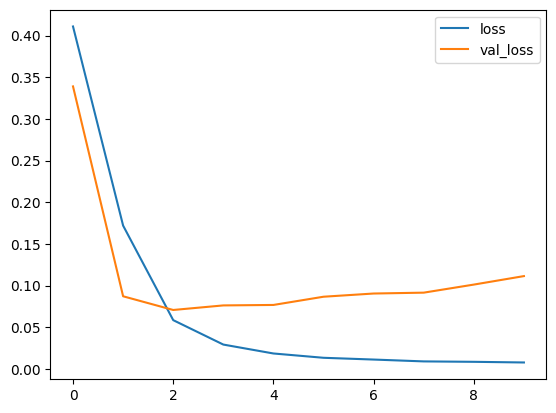

In [53]:
#plotando a loss por iteração

plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

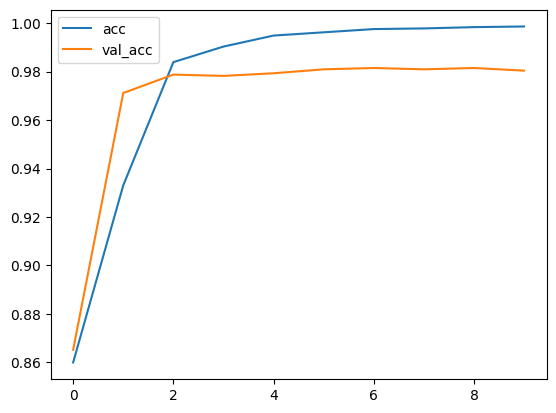

In [54]:
#plotando a acurácia por iteração

plt.plot(r.history['accuracy'], label='acc')
plt.plot(r.history['val_accuracy'], label='val_acc')
plt.legend()